TASK1: Blocker Profiling

The goal of this task is to analyze and predict blocking behavior on the Bluesky social network at the user (node) level. Specifically, we aim to model how likely a user is to block others based on their position in the social graph, their local neighborhood behavior, and their activity patterns.

The task here answers the following question: Can we predict a user’s blocking behavior from their social position and interactions, without directly using how much they block?

Importing libraries

In [62]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

Loading graph and node features

In [63]:
GRAPH_PATH = "blocks_graph.graphml"
FEATURES_PATH = "node_features.parquet"

G = nx.read_graphml(GRAPH_PATH)
node_features = pd.read_parquet(FEATURES_PATH)

print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
print("Features shape:", node_features.shape)

Graph: 32111 nodes, 190849 edges
Features shape: (32111, 13)


In [64]:
node_features.head()


,out_degree,in_degree,block_ratio,pagerank,reciprocity,posts_count,following,followers,blocks_given,blocks_received,replies,neighbor_avg_blocks,clustering
did_id,,,,,,,,,,,,,
109144,12,1,6.000000,0.000023,0.00000,169,550,407.0,45,2.0,73.0,90.333333,0.166667
29745745,18,75,0.236842,0.000141,0.00000,396,30,43.0,68,81.0,102.0,56.666667,0.086723
17362021,5,528,0.009452,0.001106,0.00000,50,122,97.0,20,575.0,26.0,53.800000,0.007716
5096582,6,730,0.008208,0.001396,0.00000,340,149,120.0,29,845.0,163.0,208.500000,0.008152
21733425,10,857,0.011655,0.001921,0.00692,475,117,92.0,78,997.0,186.0,68.400000,0.005182


Our taget is block_bucket : considering a set of features in which range will the number of blocks be?

In [65]:
blocks = node_features["blocks_given"]
print(blocks.describe())


count    32111.000000
mean        55.918937
std        503.549077
min         10.000000
25%         14.000000
50%         22.000000
75%         41.000000
max      60166.000000
Name: blocks_given, dtype: float64


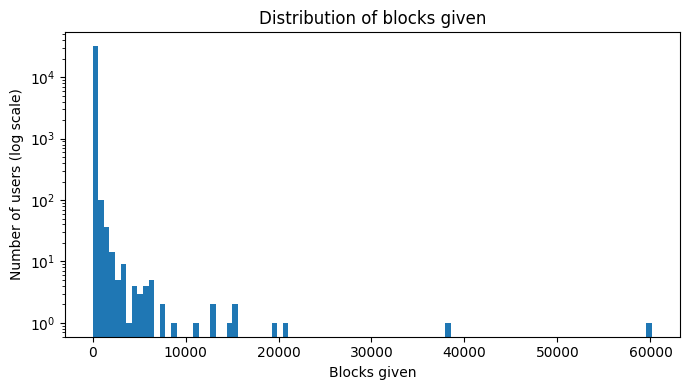

In [66]:
plt.figure(figsize=(7,4))
plt.hist(blocks, bins=100, log=True)
plt.xlabel("Blocks given")
plt.ylabel("Number of users (log scale)")
plt.title("Distribution of blocks given")
plt.tight_layout()
plt.show()


In [67]:
quantiles = blocks.quantile([0.1,0.2,0.4,0.5,0.6, 0.8, 0.9, 0.95, 0.99])
quantiles

0.10     11.0
0.20     13.0
0.40     18.0
0.50     22.0
0.60     27.0
0.80     50.0
0.90     84.0
0.95    136.0
0.99    394.6
Name: blocks_given, dtype: float64

Considering the distribution of the number of blocks we can split the population into three buckets:

    * Bucket 0: low blockers blocks < 50
    * Bucket 1: high blockers 50 < blocks given < 150
    * Bucket 2: extreme blockers blocks > 150

In [68]:
node_features["block_bucket"] = pd.cut(
    node_features["blocks_given"],
    bins=[-1, 50, 150, node_features["blocks_given"].max()],
    labels=[0, 1, 2]
).astype(int)


In [70]:
TARGET_COL = "block_bucket"

# We remove features that leak the target 
LEAKY = ["blocks_given","block_ratio","out_degree"]  

y = node_features[TARGET_COL].astype(int)
X = node_features.drop(columns=[TARGET_COL], errors="ignore")

# Remove leaky columns 
X = X.drop(columns=[c for c in LEAKY if c in X.columns], errors="ignore")

print("X shape:", X.shape, "| y distribution:")
print(y.value_counts(normalize=True).sort_index())


X shape: (32111, 10) | y distribution:
block_bucket
0    0.803058
1    0.153437
2    0.043505
Name: proportion, dtype: float64


Data preprocessing

In [71]:
X = X.copy()

# Fill NaNs (common for counts)
X = X.fillna(0)

# Log1p-transform count-like columns (keeps 0 -> 0, reduces skew)
count_like = [c for c in X.columns if any(k in c.lower() for k in ["count", "followers", "following", "blocks", "posts", "replies", "degree"])]
for c in count_like:
    X[c] = np.log1p(X[c].astype(float))

display(X.describe().T.head(15))


,count,mean,std,min,25%,50%,75%,max
in_degree,32111.0,0.960912,1.041628,0.000000,0.000000,0.693147,1.386294,8.297544
pagerank,32111.0,0.000031,0.000201,0.000008,0.000008,0.000008,0.000014,0.018204
reciprocity,32111.0,0.035725,0.127116,0.000000,0.000000,0.000000,0.000000,1.000000
posts_count,32111.0,4.924242,1.333012,1.791759,4.007333,4.997212,5.888878,9.532786
following,32111.0,4.505796,1.367835,1.791759,3.526361,4.454347,5.398163,11.432355
followers,32111.0,3.918814,1.488043,0.000000,2.890372,3.806662,4.844187,11.316010
blocks_received,32111.0,1.120953,1.114958,0.000000,0.000000,0.693147,1.609438,9.379239
replies,32111.0,4.254727,1.535744,0.000000,3.218876,4.330733,5.370638,9.503905
neighbor_avg_blocks,32111.0,3.493805,1.574167,0.000000,3.044522,3.663562,4.347437,11.004879
clustering,32111.0,0.044514,0.120206,0.000000,0.000000,0.000000,0.035714,1.000000


Train/Test split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (25688, 10) Test: (6423, 10)


Model 1: Logistic Regression

In [73]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

logreg.fit(X_train_sc, y_train)
pred_lr = logreg.predict(X_test_sc)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, digits=3))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.873     0.586     0.701      5158
           1      0.206     0.310     0.248       986
           2      0.102     0.538     0.171       279

    accuracy                          0.541      6423
   macro avg      0.393     0.478     0.373      6423
weighted avg      0.737     0.541     0.608      6423



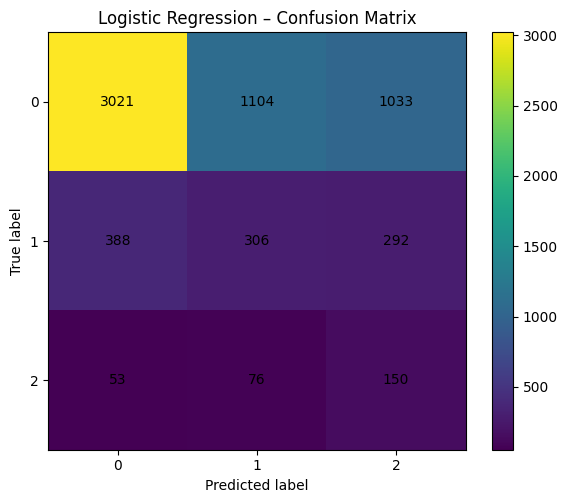

In [74]:
# Compute confusion matrix
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(cm.shape[0]))
plt.yticks(range(cm.shape[0]))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Logistic Regression – Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()


Current results tell us:

Class 0 (low blockers) --> Very strong precision and decent recall

Class 2 (extreme blockers) --> Recall is excellent (model finds) them but Precision is moderate  

Class 1 (medium blockers) --> Weak precision  and medium recall 

In order to improve performance, we apply some feature selection:

In [75]:
leakage_cols = [
    "blocks_given",
    "block_ratio",
    "block_bucket",
    "out_degree"
]

X = X.drop(columns=[c for c in leakage_cols if c in X.columns])


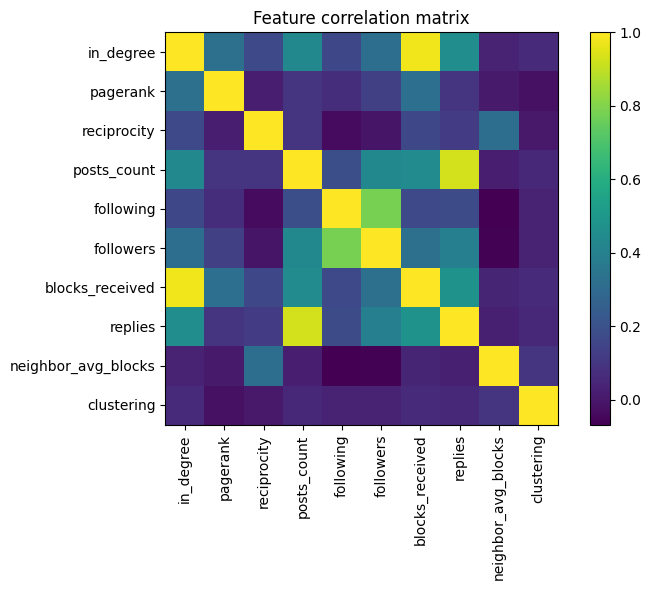

In [76]:
corr = X.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


To select features we look for: 

|corr| > 0.7 → redundant → keep only one

Prefer:
* more interpretable
* more directly tied to behavior
* less derived if two are similar

In [77]:
selected_features = [
    "in_degree",           # how much the user is blocked
    "pagerank",            # global network importance
    "reciprocity",         # mutual conflict behavior
    "replies",             # interaction intensity
    "followers",           # influence
    "neighbor_avg_blocks", # exposure to conflict
    "clustering"           # local community structure
]


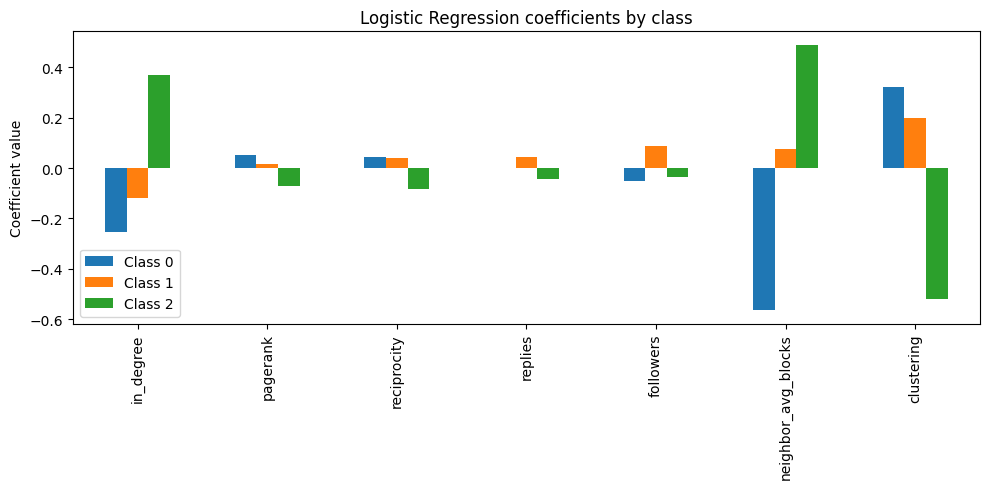

In [78]:
X_sel = X[selected_features]

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_sel)

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

logreg.fit(X_sc, y)

coef_df = pd.DataFrame(
    logreg.coef_,
    columns=X_sel.columns,
    index=["Class 0", "Class 1", "Class 2"]
)

coef_df.T.plot(
    kind="bar",
    figsize=(10, 5),
    title="Logistic Regression coefficients by class"
)

plt.ylabel("Coefficient value")
plt.tight_layout()
plt.show()

This shows that extreme blocking behavior is best explained by local activity patterns and structural isolation rather than global popularity or community norms

We retrain the model to see if the performance improves

In [79]:
from sklearn.feature_selection import RFE

rfe = RFE(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ),
    n_features_to_select=6
)

rfe.fit(X_sc, y)

rfe_features = X_sel.columns[rfe.support_]
print("Selected features:", list(rfe_features))


Selected features: ['in_degree', 'pagerank', 'reciprocity', 'followers', 'neighbor_avg_blocks', 'clustering']


In [80]:
X_final = X_sel[rfe_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

logreg.fit(X_train_sc, y_train)
pred = logreg.predict(X_test_sc)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred, digits=3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.869     0.587     0.701      5158
           1      0.194     0.287     0.232       986
           2      0.103     0.545     0.173       279

    accuracy                          0.539      6423
   macro avg      0.389     0.473     0.368      6423
weighted avg      0.732     0.539     0.606      6423



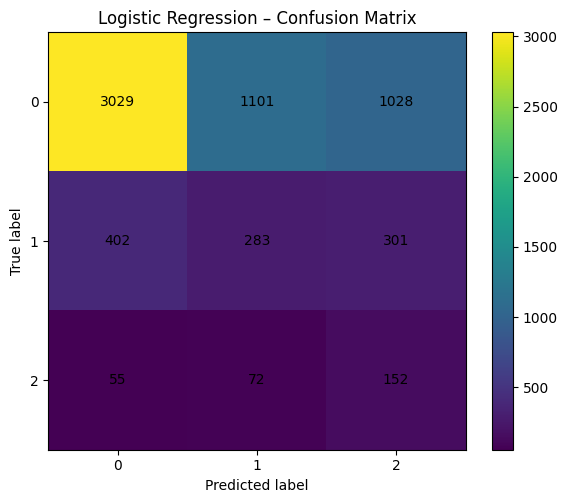

In [81]:
# Compute confusion matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(cm.shape[0]))
plt.yticks(range(cm.shape[0]))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Logistic Regression – Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

Performance is almost identical. But this proves that the dropped features were redundant and not informative. Now we can explore  another model.

Model 2: Random Forest

No scaling is needed

In [82]:
X = node_features[selected_features]
y = node_features["block_bucket"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Train and evaluate the model

In [83]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=30,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

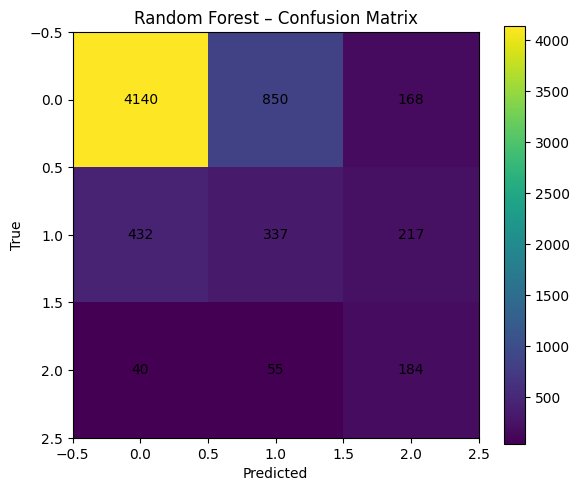

In [84]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest – Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

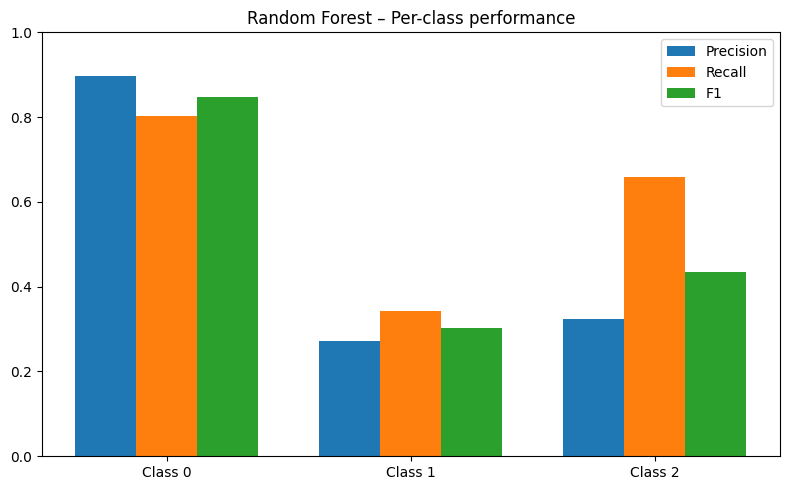

In [85]:
report = classification_report(y_test, pred_rf, output_dict=True)

classes = ["0", "1", "2"]
metrics = ["precision", "recall", "f1-score"]

vals = np.array([[report[c][m] for m in metrics] for c in classes])

x = np.arange(len(classes))
w = 0.25

plt.figure(figsize=(8,5))
plt.bar(x-w, vals[:,0], w, label="Precision")
plt.bar(x,   vals[:,1], w, label="Recall")
plt.bar(x+w, vals[:,2], w, label="F1")

plt.xticks(x, [f"Class {c}" for c in classes])
plt.ylim(0,1)
plt.title("Random Forest – Per-class performance")
plt.legend()
plt.tight_layout()
plt.show()


In [86]:
print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, digits=3))

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.898     0.803     0.847      5158
           1      0.271     0.342     0.303       986
           2      0.323     0.659     0.434       279

    accuracy                          0.726      6423
   macro avg      0.497     0.601     0.528      6423
weighted avg      0.777     0.726     0.746      6423



the performance of this model is mush higher but remains low fo class 1 and 2.

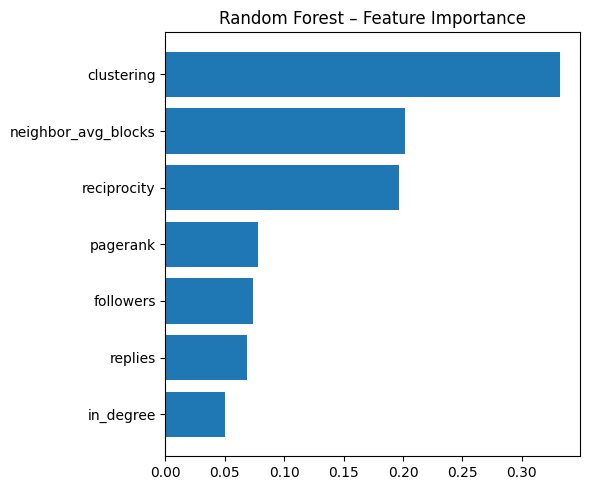

In [87]:
imp = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(6,5))
plt.barh(imp.index, imp.values)
plt.title("Random Forest – Feature Importance")
plt.tight_layout()
plt.show()


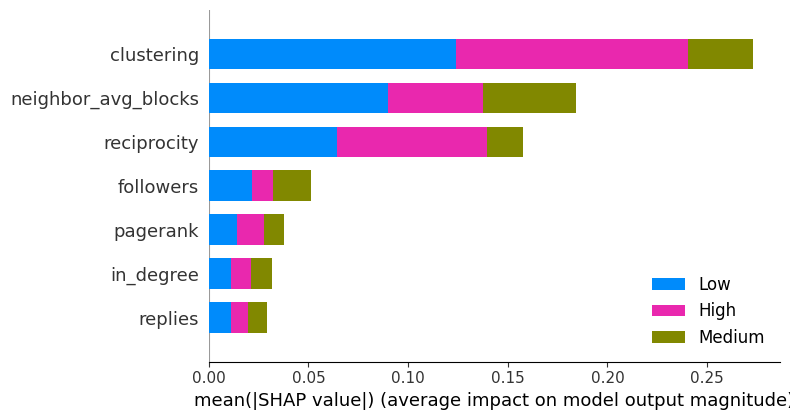

In [89]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    class_names=["Low", "Medium", "High"]
)


This shows that blocking behavior is primarily explained by graph structure, not popularity or raw activity.

bess